In [1]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # Add this line to ensure deterministic behavior
torch.use_deterministic_algorithms(True) # Needed for reproducible results

Random Seed:  999


In [19]:
# Root directory for dataset
#dataroot = "data/celeba"
dataroot = "cats_cute"

batch_size = 16
image_size = 64
nz = 64     # size of latent vector (noise)
num_epochs = 25
lrG = 0.0002
lrD = 0.0001
beta1 = 0.5
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")


In [3]:
!pip install gdown

zsh:1: command not found: pip


In [4]:
cute_cats = "cats.zip"


In [5]:
import zipfile
import os

# Path to zip file in project folder
zip_file = "cats.zip"

# Folder to extract images
extract_folder = "cute_cats"
os.makedirs(extract_folder, exist_ok=True)

# Extract files
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"All files extracted to '{extract_folder}'")

# List first 20 files
all_files = os.listdir(extract_folder)
print(f"Found {len(all_files)} files:")
for f in all_files[:20]:
    print(f)


All files extracted to 'cute_cats'
Found 2 files:
cats
__MACOSX


In [7]:
import shutil

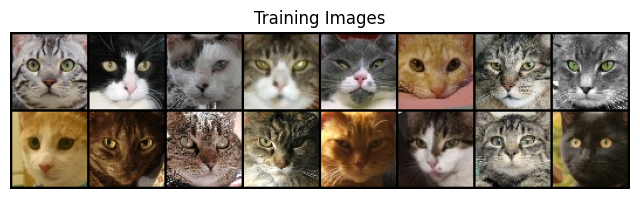

In [21]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torchvision.datasets as dset
from torchvision import transforms

# --- Config ---
dataroot = "cute_cats"  # folder with extracted cat images

workers = 0  # safe for Mac
ngpu = 0     # use CPU

# --- Remove macOS hidden files (optional) ---
macosx_path = os.path.join(dataroot, '__MACOSX')
if os.path.exists(macosx_path):
    shutil.rmtree(macosx_path)

for root, dirs, files in os.walk(dataroot):
    for file in files:
        if file.startswith('._'):
            os.remove(os.path.join(root, file))

# --- Dataset and Dataloader ---
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
                           ]))

dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# --- Device ---
device = torch.device("cpu")  # Mac will use CPU

# --- Plot some images ---
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:64], padding=2, normalize=True), (1,2,0)))
plt.show()


In [22]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [23]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [24]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),

        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)


In [25]:
netG = Generator().to(device)
netD = Discriminator().to(device)

# Weight initialization
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

In [26]:
criterion = nn.BCEWithLogitsLoss()

optimizerD = optim.Adam(netD.parameters(), lr=lrD, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lrG, betas=(beta1, 0.999))

In [31]:
real_label = 0.9  # label smoothing for real images
fake_label = 0.1  # small smoothing for fake images

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        ############################
        # (1) Update Discriminator
        ############################
        netD.zero_grad()
        real_images = data[0].to(device)
        batch_size_curr = real_images.size(0)

        # Add tiny noise to real images (instance noise)
        real_images_noisy = real_images + 0.05 * torch.randn_like(real_images)

        # Train on real images
        labels_real = torch.full((batch_size_curr,), real_label, device=device)
        output_real = netD(real_images_noisy)
        lossD_real = criterion(output_real, labels_real)
        lossD_real.backward()

        # Train on fake images
        noise = torch.randn(batch_size_curr, nz, 1, 1, device=device)
        fake_images = netG(noise)
        labels_fake = torch.full((batch_size_curr,), fake_label, device=device)
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, labels_fake)
        lossD_fake.backward()
        optimizerD.step()

        lossD = lossD_real + lossD_fake

        ############################
        # (2) Update Generator
        ############################
        netG.zero_grad()
        # try to fool the discriminator
        labels_gen = torch.full((batch_size_curr,), real_label, device=device)
        output_gen = netD(fake_images)  # do NOT detach
        lossG = criterion(output_gen, labels_gen)
        lossG.backward()
        optimizerG.step()

        ############################
        # Logging
        ############################
        if i % 50 == 0:
            D_x = output_real.mean().item()
            D_G_z = output_fake.mean().item()
            print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] "
                  f"Loss_D: {lossD.item():.4f} Loss_G: {lossG.item():.4f} "
                  f"D(x): {D_x:.4f} D(G(z)): {D_G_z:.4f}")

    # Optional: reduce instance noise slightly each epoch
    # noise_std = max(0, 0.05 * (1 - epoch / num_epochs))


[0/25][0/985] Loss_D: 1.1515 Loss_G: 1.8484 D(x): 1.4932 D(G(z)): -0.3650
[0/25][50/985] Loss_D: 0.9838 Loss_G: 1.8640 D(x): 1.0026 D(G(z)): -1.0882
[0/25][100/985] Loss_D: 1.0626 Loss_G: 1.5647 D(x): 0.2322 D(G(z)): -1.3470
[0/25][150/985] Loss_D: 1.1447 Loss_G: 1.7044 D(x): 0.2015 D(G(z)): -1.5568
[0/25][200/985] Loss_D: 1.3505 Loss_G: 1.9785 D(x): 0.7311 D(G(z)): -0.4569
[0/25][250/985] Loss_D: 1.2627 Loss_G: 1.6772 D(x): 0.8881 D(G(z)): -0.2545
[0/25][300/985] Loss_D: 1.0512 Loss_G: 2.1738 D(x): 1.1098 D(G(z)): -1.1071
[0/25][350/985] Loss_D: 1.0689 Loss_G: 1.7397 D(x): 0.7565 D(G(z)): -0.8427
[0/25][400/985] Loss_D: 1.0691 Loss_G: 1.8228 D(x): 0.8897 D(G(z)): -0.5957
[0/25][450/985] Loss_D: 1.1284 Loss_G: 2.5129 D(x): 1.6949 D(G(z)): -0.1850
[0/25][500/985] Loss_D: 1.3448 Loss_G: 1.7096 D(x): 0.3413 D(G(z)): -0.2485
[0/25][550/985] Loss_D: 1.1955 Loss_G: 1.9065 D(x): 0.8117 D(G(z)): -0.3854
[0/25][600/985] Loss_D: 1.1719 Loss_G: 1.7821 D(x): 0.5000 D(G(z)): -0.5942
[0/25][650/985]

KeyboardInterrupt: 

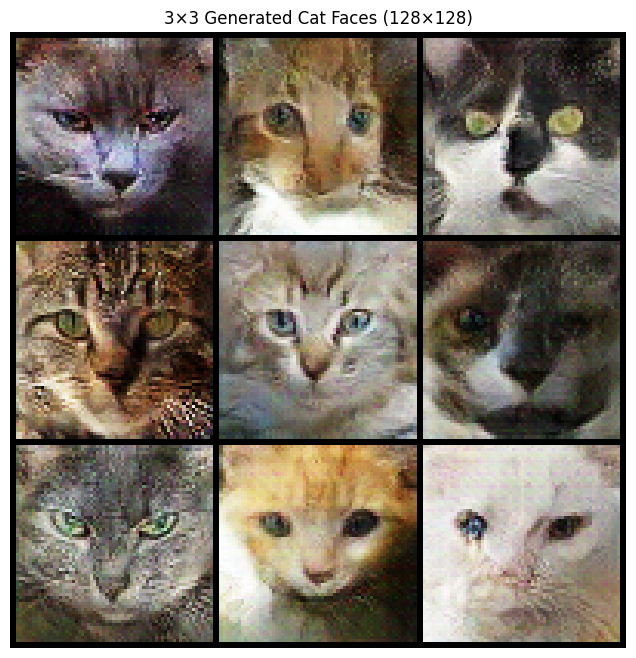

In [ ]:
with torch.no_grad():
    z = torch.randn(9, nz, 1, 1, device=device)
    fake_images = netG(z).cpu()

grid = vutils.make_grid(fake_images, nrow=3, padding=2, normalize=True)

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("3×3 Generated Cat Faces (128×128)")
plt.imshow(np.transpose(grid, (1,2,0)))
plt.show()
